In [ ]:
# %% import libraries

import numpy as np
from pathlib import Path
from scipy.sparse import csr_matrix, vstack
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
# %% load data

N = None
batch_dir = Path("./data/sae_vectors")
batch_files = sorted(batch_dir.glob("confirmatory_preprocessed_sae_vectors_sparse_minibatch_*.npz"))
batch_files = batch_files[:N] if N is not None else batch_files

Xs = []
for f in batch_files:
    z = np.load(f)
    Xs.append(csr_matrix((z["data"], z["indices"], z["indptr"]), shape=tuple(z["shape"])))

X = vstack(Xs, format="csr")  # rows = examples
# print(X.shape, X.nnz)

best_files = sorted(batch_dir.glob("confirmatory_preprocessed_sae_vectors_best_minibatch_*.npy"))
best_files = best_files[:N] if N is not None else best_files
y = np.concatenate([np.load(f).reshape(-1) for f in best_files], axis=0)
# print(y.shape)

In [ ]:
# %% split data (by pairs to avoid data leakage)

# Each pair has 2 rows: row 2i = best-worst, row 2i+1 = worst-best
# We must keep pairs together since worst-best = -1 * (best-worst)
print("Splitting data into train and test sets (by pair)...")
n_pairs = X.shape[0] // 2
pair_indices = np.arange(n_pairs)

# Split at the pair level
train_pairs, test_pairs = train_test_split(pair_indices, test_size=0.2, random_state=42)

# Convert pair indices to row indices
train_idx = np.sort(np.concatenate([train_pairs * 2, train_pairs * 2 + 1]))
test_idx = np.sort(np.concatenate([test_pairs * 2, test_pairs * 2 + 1]))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f"Train: {len(train_pairs)} pairs ({X_train.shape[0]} rows), Test: {len(test_pairs)} pairs ({X_test.shape[0]} rows)")

Splitting data into train and test sets (by pair)...
Train: 10777 pairs (21554 rows), Test: 2695 pairs (5390 rows)


In [ ]:
# %% standardize features

scaler = StandardScaler(with_mean=False)
# scaler = MaxAbsScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# %% train logistic regression

print("Training logistic regression model...")

# model = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0001, max_iter=2000, tol=1e-3, verbose=1, n_jobs=-1, random_state=0)

model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=1 
)

model.fit(X_train, y_train)

Training logistic regression model...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [ ]:
# %% evaluate model

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))
# print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7092764378478664
              precision    recall  f1-score   support

           0       0.70      0.73      0.72      2695
           1       0.72      0.68      0.70      2695

    accuracy                           0.71      5390
   macro avg       0.71      0.71      0.71      5390
weighted avg       0.71      0.71      0.71      5390



In [ ]:
# %% feature importance

if isinstance(model, SGDClassifier):
    feature_importances = model.coef_
elif isinstance(model, XGBClassifier):
    feature_importances = model.feature_importances_.reshape(1, -1)
else:
    raise ValueError("Unsupported model type for feature importance extraction.")

top10 = np.argsort(feature_importances.flatten())[-10:][::-1]
bottom10 = np.argsort(feature_importances.flatten())[:10]
print("\nTop 10 feature indices and importance scores:")
for idx in top10:
    print(f"Feature {idx}: {feature_importances[0][idx]}")
print("\nBottom 10 feature indices and importance scores:")
for idx in bottom10:
    print(f"Feature {idx}: {feature_importances[0][idx]}")


Top 10 feature indices and importance scores:
Feature 1531: 0.0029667848721146584
Feature 11052: 0.0029070614837110043
Feature 1389: 0.002652724739164114
Feature 2727: 0.0025454084388911724
Feature 3669: 0.002351522445678711
Feature 538: 0.0023318335879594088
Feature 2400: 0.0018853547517210245
Feature 1213: 0.001845110789872706
Feature 444: 0.0018144473433494568
Feature 12139: 0.001767763402312994

Bottom 10 feature indices and importance scores:
Feature 10820: 0.0
Feature 10805: 0.0
Feature 10806: 0.0
Feature 10807: 0.0
Feature 10808: 0.0
Feature 10809: 0.0
Feature 10810: 0.0
Feature 10811: 0.0
Feature 10812: 0.0
Feature 10813: 0.0


In [ ]:
# %% get feature names from neuronpedia

from IPython.display import IFrame
html_template = "https://neuronpedia.org/{}/{}/{}?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300"
# example_url = "https://neuronpedia.org/gemma-3-4b-it/22-gemmascope-2-res-16k/1500?embed=true&embedexplanation=true&embedplots=true&embedtest=true&height=300"

def get_dashboard_html(sae_release = "gemma-3-4b-it", sae_id="22-gemmascope-2-res-16k", feature_idx=0):
    return html_template.format(sae_release, sae_id, feature_idx)

html = get_dashboard_html(feature_idx=top10[0])
IFrame(html, width=1200, height=600)

In [ ]:
# %% get explanations

# class exact match: "text-left font-sans text-[11.5px] sm:text-[13px]"
# if it exists
import requests
from bs4 import BeautifulSoup
def get_explanation(url):
    response = requests.get(url)
    html_content = response.text
    soup = BeautifulSoup(html_content, 'html.parser')
    explanation = soup.find_all(class_="text-left font-sans text-[11.5px] sm:text-[13px]")
    if explanation:
        return explanation[0].text
    return None

print("\nTop 10 feature explanations:")
for feature_idx in top10:
    url = get_dashboard_html(feature_idx=feature_idx)
    explanation = get_explanation(url)
    print(f"Feature {feature_idx}: {explanation}")

print("\nBottom 10 feature explanations:")
for feature_idx in bottom10:
    url = get_dashboard_html(feature_idx=feature_idx)
    explanation = get_explanation(url)
    print(f"Feature {feature_idx}: {explanation}")


Top 10 feature explanations:
Feature 1531: discovery and revelation
Feature 11052: How to write clickbait titles
Feature 1389: The neuron activates on framing or context-setting phrases—words used to acknowledge or reference the situation (e.g. “Regarding the situation,” “acknowledging the situation”).
Feature 2727: internet social media slang
Feature 3669: video content and analysis
Feature 538: restrict public trade abides necessitate
Feature 2400: a, say, have sequences
Feature 1213: identifying and flagging explicit or policy-violating content (particularly violent, sexual, or dangerous material).
Feature 444: abstract conceptual nouns and nominalizations denoting qualities, states, or processes (e.g., “-ion/-ity/-ness/-ment” forms)
Feature 12139: questions and technical topics

Bottom 10 feature explanations:
Feature 10820: commas followed by country names
Feature 10805: scene understanding
Feature 10806: family members and their actions
Feature 10807: bin and lib directories
Fea

/home/drew99/IJS/hierarchical-hypothe-sae/.venv-ml/lib/python3.10/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


<Figure size 300000x200000 with 0 Axes>

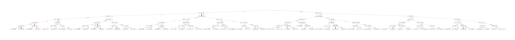

In [ ]:
# %%

from xgboost import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(3000, 2000))  
plot_tree(model, num_trees=1) 
#save pdf 300 dpi
plt.savefig("xgboost_tree.pdf", dpi=300, bbox_inches='tight')
plt.show()

/home/drew99/IJS/hierarchical-hypothe-sae/.venv-ml/lib/python3.10/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


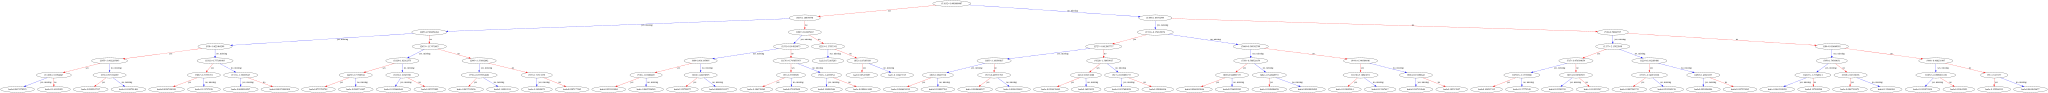

In [ ]:
# %% graphviz .dot

import graphviz
import xgboost as xgb
import os
tree_dot = xgb.to_graphviz(model, num_trees=2)
# Save the dot file
dot_file_path = "xgboost_tree.dot"
tree_dot.save(dot_file_path)
# Convert dot file to png and display
with open(dot_file_path) as f:
    dot_graph = f.read()
# Use graphviz to display the tree
graph = graphviz.Source(dot_graph)
graph.render("xgboost_tree")
# Optionally, visualize the graph directly
graph

/home/drew99/IJS/hierarchical-hypothe-sae/.venv-ml/lib/python3.10/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


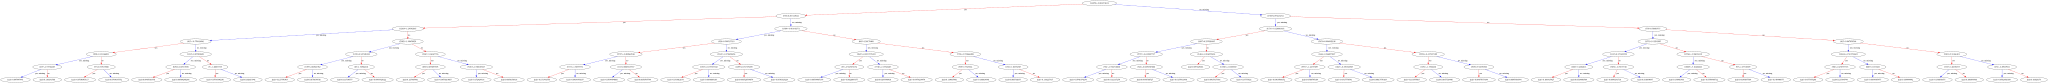

In [ ]:
# %% graphviz .dot

import graphviz
import xgboost as xgb
import os
tree_dot = xgb.to_graphviz(model, num_trees=1)
# Save the dot file
dot_file_path = "xgboost_tree1.dot"
tree_dot.save(dot_file_path)
# Convert dot file to png and display
with open(dot_file_path) as f:
    dot_graph = f.read()
# Use graphviz to display the tree
graph = graphviz.Source(dot_graph)
graph.render("xgboost_tree1")
# Optionally, visualize the graph directly
graph